# Dense GAN for MNIST Zeros

This project turns the original `GANs.ipynb` scratch notebook into a clean, runnable baseline for adversarial image generation. The model trains on the zero class from MNIST so the training loop stays light enough for CPU runs while still showing the key GAN dynamics.


## Goal

Train a dense generator and discriminator pair that can synthesize `28x28` handwritten zeros from random latent vectors.

## Data

- Source: `data/mnist.pkl.gz`
- Training slice: the first `4,096` zero digits from MNIST training data
- Holdout slice: zero digits from the MNIST test split

## What to look for

- how the generator samples sharpen as training progresses
- how the discriminator becomes less certain on synthetic digits
- where a simple dense GAN still shows limitations compared with a DCGAN


In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import gzip
import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

warnings.filterwarnings('ignore', category=UserWarning, module='keras')
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(7)
tf.random.set_seed(7)
rng = np.random.default_rng(7)

DATA_PATH = Path('data/mnist.pkl.gz')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Missing dataset: {DATA_PATH}')

print('TensorFlow version:', tf.__version__)
print('Dataset path:', DATA_PATH.resolve())


TensorFlow version: 2.17.1
Dataset path: C:\Users\daniy\OneDrive\Documents\mnist-zero-gan\data\mnist.pkl.gz


Training zeros: 4096
Holdout zeros: 980
Image shape: (28, 28, 1)


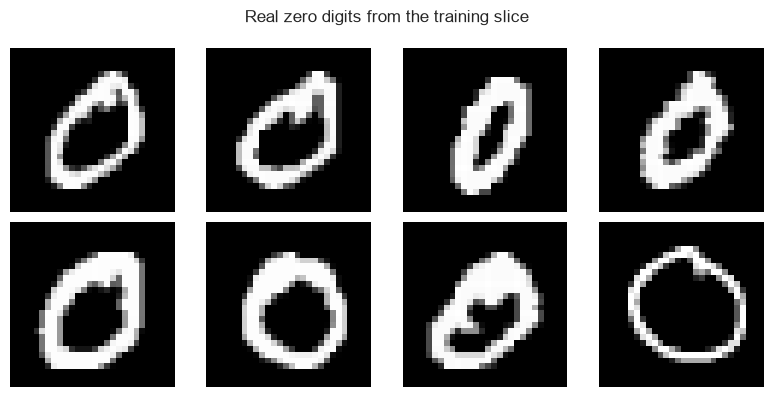

In [2]:
with gzip.open(DATA_PATH, 'rb') as handle:
    (x_train, y_train), (x_test, y_test) = pickle.load(handle, encoding='latin1')

zero_train = (x_train[y_train == 0].astype('float32') / 255.0)[..., None]
zero_test = (x_test[y_test == 0].astype('float32') / 255.0)[..., None]
train_images = zero_train[:4096]

print('Training zeros:', len(train_images))
print('Holdout zeros:', len(zero_test))
print('Image shape:', train_images.shape[1:])

fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for ax, image in zip(axes.flat, train_images[:8]):
    ax.imshow(image.squeeze(), cmap='gray')
    ax.axis('off')
fig.suptitle('Real zero digits from the training slice')
plt.tight_layout()
plt.show()


## Model

The generator maps a `64`-dimensional latent vector to a grayscale digit image. The discriminator scores whether an image looks real or generated. This is intentionally a dense baseline rather than a convolutional GAN so the training logic stays transparent.


In [3]:
latent_dim = 64
batch_size = 128
epochs = 20
snapshot_epochs = {1, 5, 10, 20}


generator = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(latent_dim,)),
    tf.keras.layers.Dense(128),
    tf.keras.layers.LeakyReLU(negative_slope=0.2),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(256),
    tf.keras.layers.LeakyReLU(negative_slope=0.2),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(28 * 28, activation='sigmoid'),
    tf.keras.layers.Reshape((28, 28, 1)),
], name='generator')


discriminator = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128),
    tf.keras.layers.LeakyReLU(negative_slope=0.2),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(64),
    tf.keras.layers.LeakyReLU(negative_slope=0.2),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(1, activation='sigmoid'),
], name='discriminator')

bce = tf.keras.losses.BinaryCrossentropy()
g_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.5)
d_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.5)

generator.summary()
discriminator.summary()


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 784)            │       201,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,368 (954.56 KB)

 Trainable params: 243,600 (951.56 KB)

 Non-trainable params: 768 (3.00 KB)

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,801 (425.00 KB)

 Trainable params: 108,801 (425.00 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
def make_batches(images, batch_size, rng):
    order = rng.permutation(len(images))
    for start in range(0, len(order) - batch_size + 1, batch_size):
        ids = order[start:start + batch_size]
        yield tf.convert_to_tensor(images[ids])


def plot_image_grid(images, title, columns=4):
    rows = int(np.ceil(len(images) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(columns * 2, rows * 2))
    axes = np.atleast_2d(axes)
    for ax, image in zip(axes.flat, images):
        ax.imshow(image.squeeze(), cmap='gray')
        ax.axis('off')
    for ax in axes.flat[len(images):]:
        ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def train_gan(train_images, epochs, batch_size):
    history = {'d_loss': [], 'g_loss': [], 'real_score': [], 'fake_score': []}
    fixed_noise = tf.random.normal([16, latent_dim], seed=7)
    snapshots = {}

    for epoch in range(1, epochs + 1):
        epoch_d_losses = []
        epoch_g_losses = []
        epoch_real_scores = []
        epoch_fake_scores = []

        for real_batch in make_batches(train_images, batch_size, rng):
            noise = tf.random.normal([batch_size, latent_dim])
            with tf.GradientTape() as d_tape, tf.GradientTape() as g_tape:
                fake_batch = generator(noise, training=True)
                real_pred = discriminator(real_batch, training=True)
                fake_pred = discriminator(fake_batch, training=True)

                real_targets = tf.ones_like(real_pred) * 0.9
                fake_targets = tf.zeros_like(fake_pred)

                d_loss = bce(real_targets, real_pred) + bce(fake_targets, fake_pred)
                g_loss = bce(tf.ones_like(fake_pred), fake_pred)

            d_grads = d_tape.gradient(d_loss, discriminator.trainable_variables)
            g_grads = g_tape.gradient(g_loss, generator.trainable_variables)
            d_optimizer.apply_gradients(zip(d_grads, discriminator.trainable_variables))
            g_optimizer.apply_gradients(zip(g_grads, generator.trainable_variables))

            epoch_d_losses.append(float(d_loss.numpy()))
            epoch_g_losses.append(float(g_loss.numpy()))
            epoch_real_scores.append(float(tf.reduce_mean(real_pred).numpy()))
            epoch_fake_scores.append(float(tf.reduce_mean(fake_pred).numpy()))

        history['d_loss'].append(float(np.mean(epoch_d_losses)))
        history['g_loss'].append(float(np.mean(epoch_g_losses)))
        history['real_score'].append(float(np.mean(epoch_real_scores)))
        history['fake_score'].append(float(np.mean(epoch_fake_scores)))

        if epoch in snapshot_epochs:
            snapshots[epoch] = generator(fixed_noise, training=False).numpy()
            print(
                f"Epoch {epoch:02d} | "
                f"d_loss={history['d_loss'][-1]:.3f} | "
                f"g_loss={history['g_loss'][-1]:.3f} | "
                f"real_score={history['real_score'][-1]:.3f} | "
                f"fake_score={history['fake_score'][-1]:.3f}"
            )

    return history, snapshots


history, snapshots = train_gan(train_images=train_images, epochs=epochs, batch_size=batch_size)


Epoch 01 | d_loss=0.779 | g_loss=1.687 | real_score=0.691 | fake_score=0.241


Epoch 05 | d_loss=0.371 | g_loss=5.907 | real_score=0.873 | fake_score=0.012


Epoch 10 | d_loss=0.354 | g_loss=9.190 | real_score=0.880 | fake_score=0.006


Epoch 20 | d_loss=0.369 | g_loss=16.267 | real_score=0.875 | fake_score=0.019


## Training Curves and Samples

The discriminator should start very confident, while the generator slowly learns to place bright pixels around the circular stroke of the digit. Because this is still a simple dense GAN, the samples remain soft and some collapse pressure is visible.


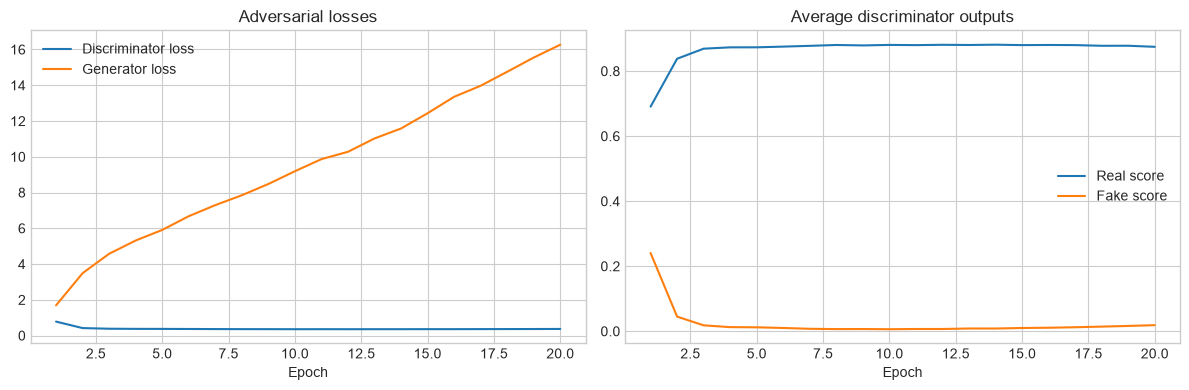

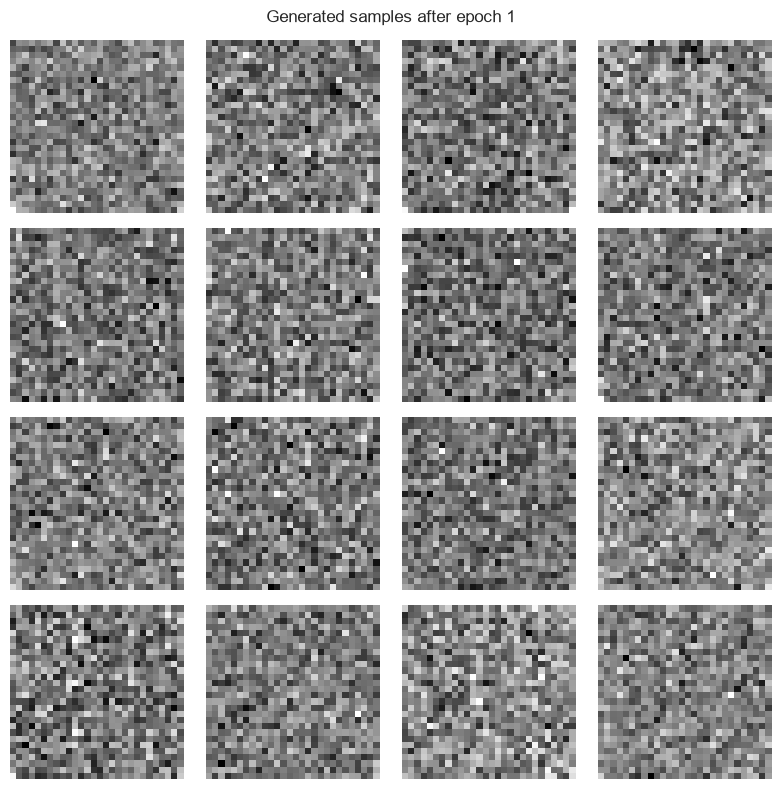

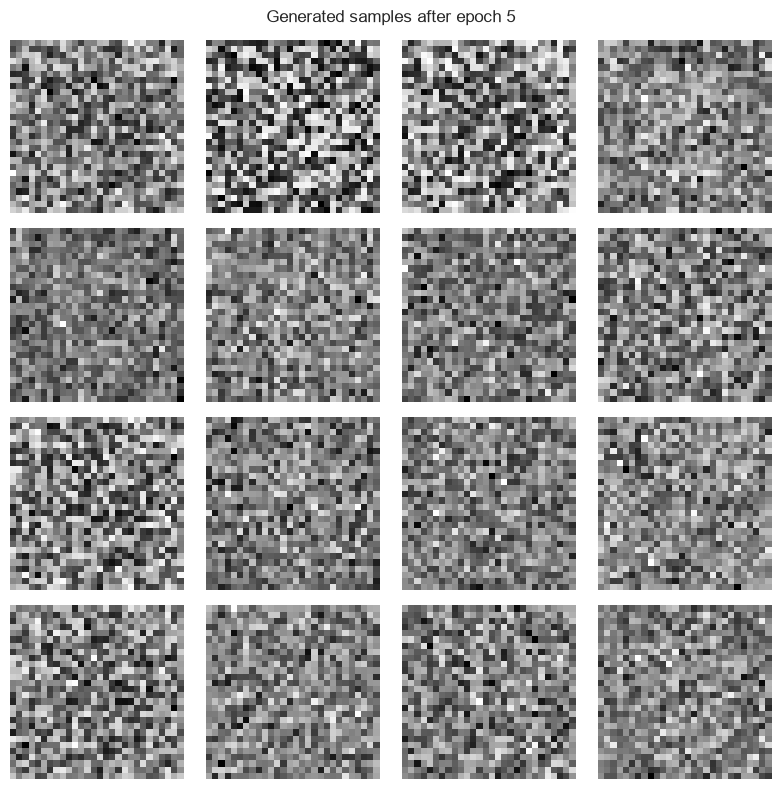

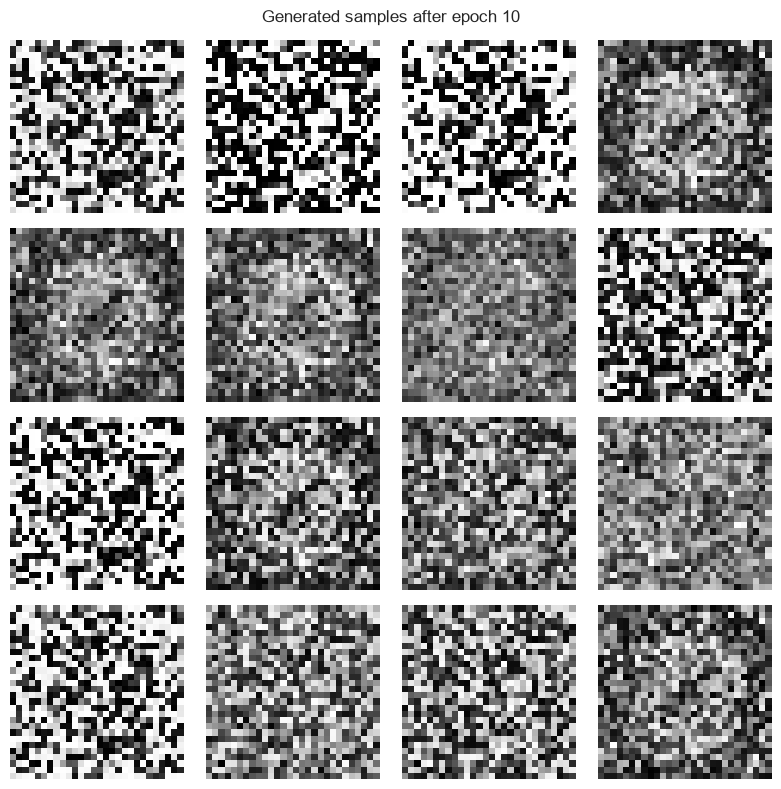

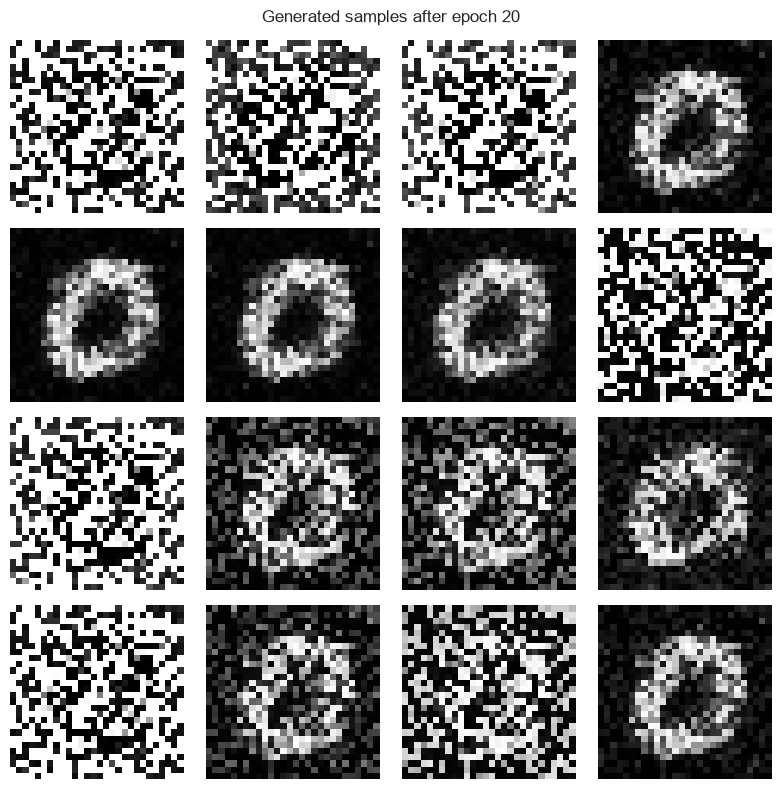

In [5]:
epochs_axis = np.arange(1, epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_axis, history['d_loss'], label='Discriminator loss')
axes[0].plot(epochs_axis, history['g_loss'], label='Generator loss')
axes[0].set_title('Adversarial losses')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs_axis, history['real_score'], label='Real score')
axes[1].plot(epochs_axis, history['fake_score'], label='Fake score')
axes[1].set_title('Average discriminator outputs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

for epoch, images in snapshots.items():
    plot_image_grid(images, title=f'Generated samples after epoch {epoch}')


## Evaluation

GAN quality is hard to summarize with a single metric, so here I use a few practical checks:

- discriminator confidence on holdout real zeros vs generated samples
- average pixel-wise diversity across generated digits
- a quick comparison between center mass and border mass, which hints whether the model learned to concentrate strokes near the middle of the image


In [6]:
generated_eval = generator(tf.random.normal([256, latent_dim], seed=11), training=False).numpy()
real_scores = discriminator(zero_test[:256], training=False).numpy().ravel()
fake_scores = discriminator(generated_eval, training=False).numpy().ravel()

pixel_diversity = float(np.mean(np.std(generated_eval, axis=0)))
center_mass = float(generated_eval[:, 8:20, 8:20, 0].mean())
border_values = np.concatenate([
    generated_eval[:, :4, :, 0].reshape(len(generated_eval), -1),
    generated_eval[:, -4:, :, 0].reshape(len(generated_eval), -1),
], axis=1)
border_mass = float(border_values.mean())

print(f'Holdout real score: {real_scores.mean():.4f}')
print(f'Generated fake score: {fake_scores.mean():.4f}')
print(f'Pixel diversity: {pixel_diversity:.4f}')
print(f'Center mass: {center_mass:.4f}')
print(f'Border mass: {border_mass:.4f}')


Holdout real score: 0.8824
Generated fake score: 0.0312
Pixel diversity: 0.3652
Center mass: 0.4350
Border mass: 0.2609


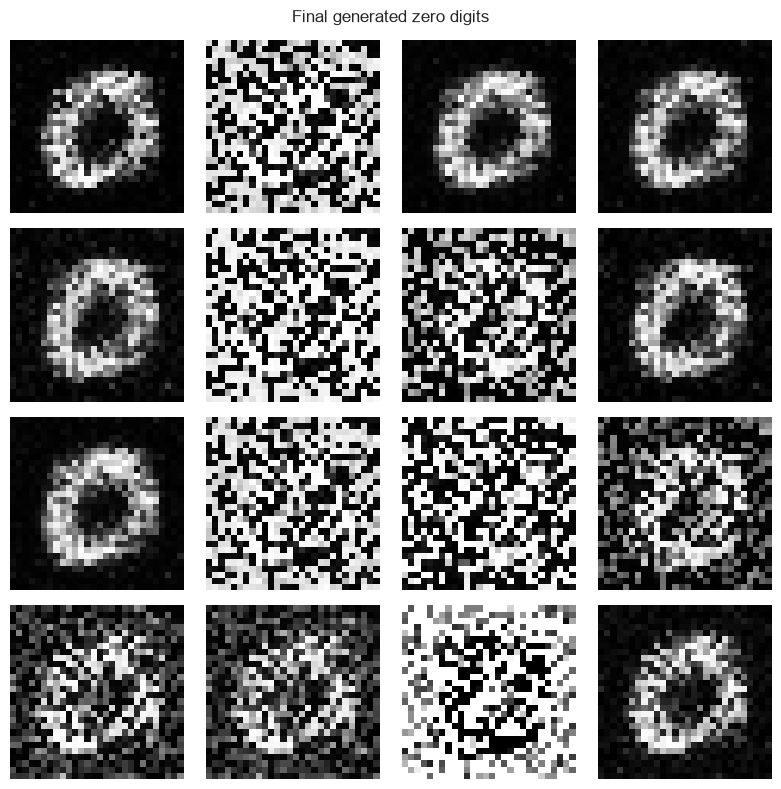

In [7]:
plot_image_grid(generated_eval[:16], title='Final generated zero digits')


## What I Learned

A dense GAN can already learn the rough shape of a handwritten zero from a modest amount of data, but it still struggles to keep sample quality and diversity balanced. That tradeoff is exactly why the convolutional upgrade in the separate DCGAN notebook matters.

## Limits

- the model only trains on the zero class, so it does not cover the full MNIST distribution
- the dense architecture is easier to read than a DCGAN, but it produces blurrier images
- GAN losses are useful for trend-checking, not for claiming final image quality on their own
